# 13 — THEME attention first derivative vs anchor ETF price

Notebook 12's velocity view, through the THEME lens: how fast is attention
on each theme accelerating or collapsing, drawn against the theme's anchor
ETF. The derivative (change vs the previous period) leads the raw counts —
this is the "speed" chart the take-off detection runs on.

Themes with a young anchor ETF (IBIT, MAGS, EUAD...) plot from the ETF's
first real price date, with a marker showing where price data begins.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2020-06-08 -> 2023-01-08


In [2]:
HOW_MANY = 6      # how many top themes to plot
# DEFAULTS TUNED FOR THE TRADING VIEW: the last 1-2 months, day by day.
# For a multi-year regime view use FREQ='W', PLOT_LAST_DAYS=None, DERIV_SMOOTH=4.
FREQ = 'D'        # 'D' daily (high fidelity), 'W' weekly, 'M' monthly
WINDOW = 7        # daily rolling window the derivative is taken over
X_TICKS = 'W'     # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = 60     # zoom to the last N days (None = whole window)
NORMALISE = True  # derivative of the mention SHARE (%), not raw counts - share of all THEME mentions
MIN_TOTAL = 30    # mask days with fewer total theme mentions than this
DERIV_SMOOTH = 5  # moving average over this many periods (days here) - short
                  # enough to react within a week, long enough to kill the
                  # day-to-day sawtooth

auto themes (most mentioned): ['crypto', 'rates_bonds', 'financials', 'consumer_retail', 'ai_megacap', 'meme_stocks']
skip crypto - no anchor ETF
note rates_bonds - no TLT price in this window (TLT starts 2026-06-08)


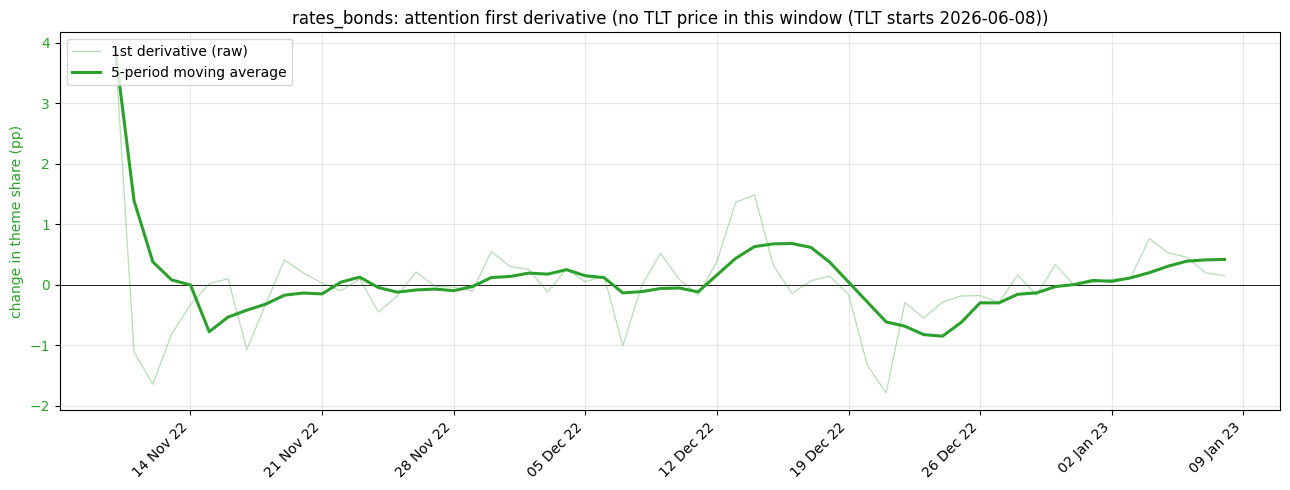

note financials - no XLF price in this window (XLF starts 2026-06-08)


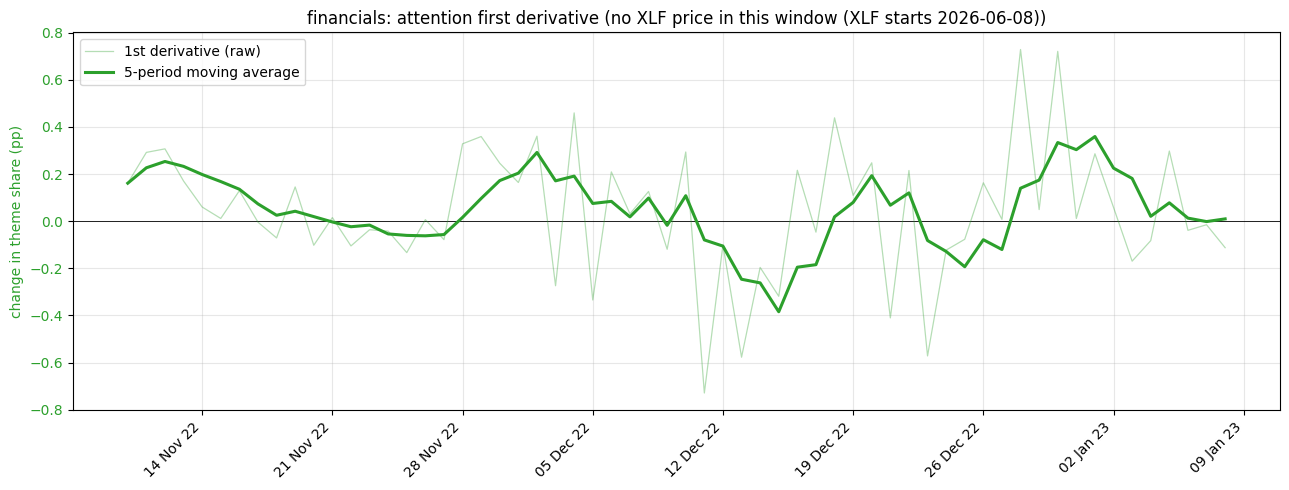

note consumer_retail - no XLY price in this window (XLY starts 2026-06-08)


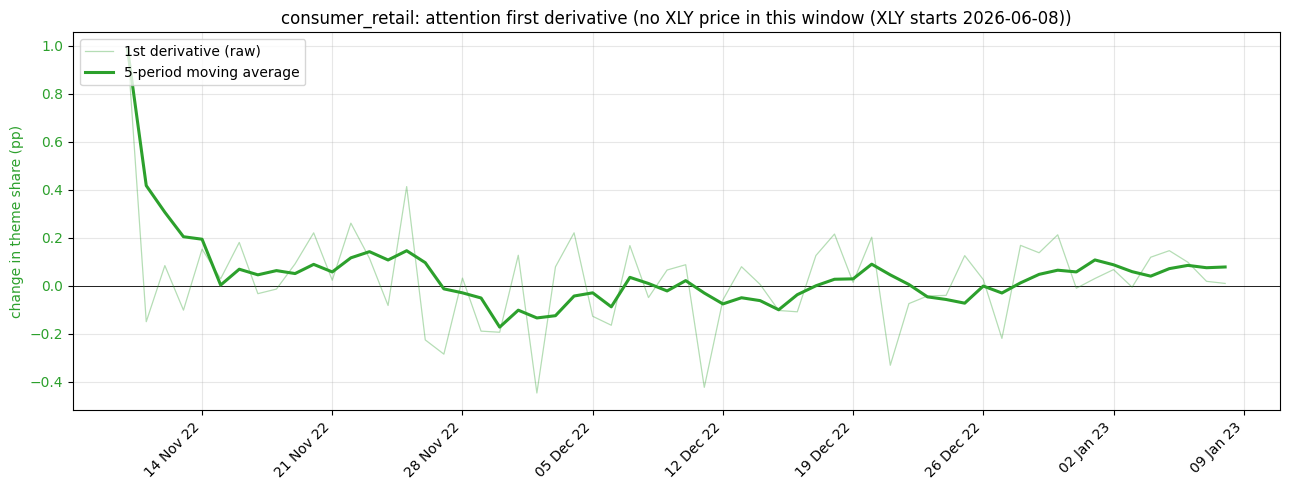

note ai_megacap - no QQQ price in this window (QQQ starts 2026-06-08)


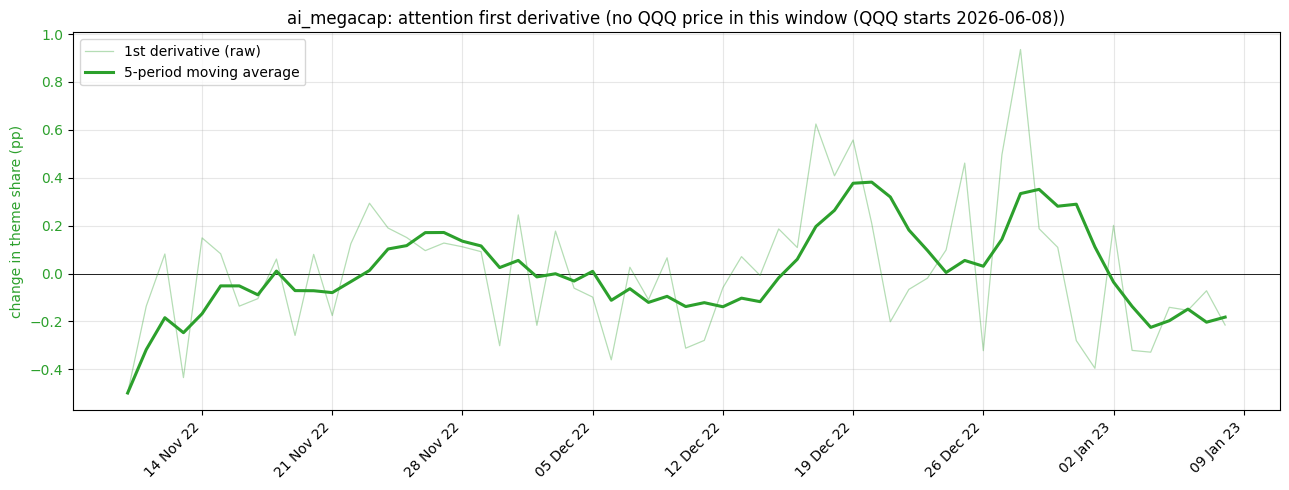

note meme_stocks - no ARKK price in this window (ARKK starts 2026-06-08)


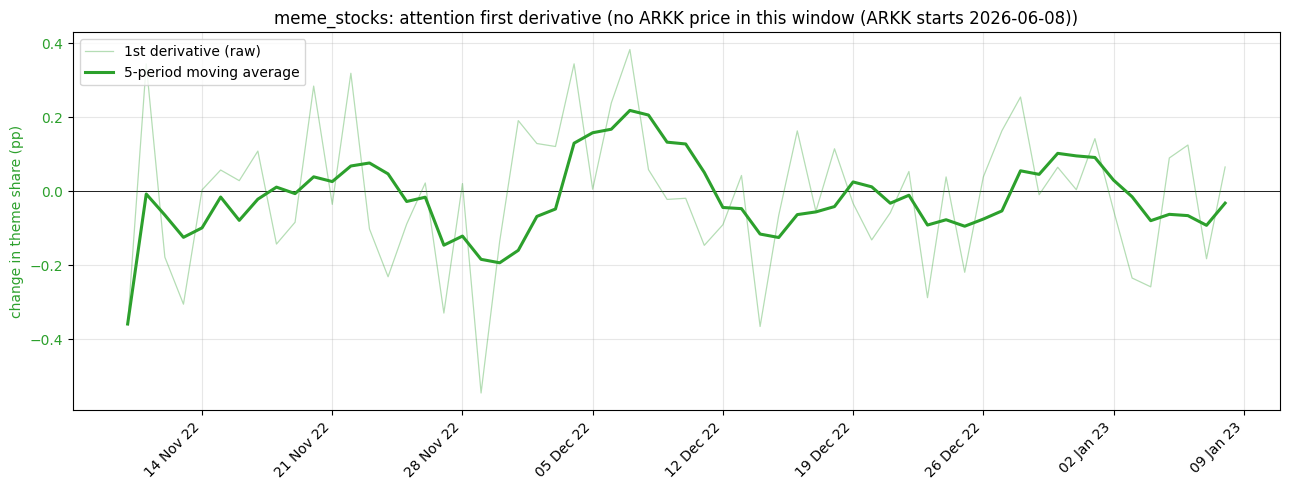

In [3]:
from src.themes import THEME_ETFS

counts = pd.read_parquet(os.path.join(P, 'daily_theme_counts.parquet'))
# aggregates carry 'mention_count'; older notebook-04 output carries
# keyword/inferred columns - handle both
if 'mention_count' not in counts.columns:
    counts['mention_count'] = (counts.get('keyword_count', 0)
                               + counts.get('inferred_count', 0))
counts['date'] = pd.to_datetime(counts['date']); counts = clip_dates(counts, 'date')
if PLOT_LAST_DAYS:                       # zoom: only the most recent stretch
    WIN_LO = max(WIN_LO, counts['date'].max() - pd.Timedelta(days=PLOT_LAST_DAYS))
    counts = counts[counts['date'] >= WIN_LO]
if counts.empty:
    print('!' * 72)
    print(f'NO AGGREGATE DATA in this window ({START_DATE} -> {END_DATE or "today"}).')
    print('The aggregates only span what was last built. Fix: run')
    print("  python update_data.py --full   (builds them over ALL history once),")
    print('then any window works. See the WINDOW CHECK in the run log for which')
    print('sources cover which dates.')
    print('!' * 72)
day_totals = counts.groupby('date')['mention_count'].sum()

themes = counts.groupby('theme')['mention_count'].sum().sort_values(ascending=False).head(HOW_MANY).index.tolist()
print('auto themes (most mentioned):', themes)
prices = load_prices()

for theme in themes:
    etf = THEME_ETFS.get(theme)
    if etf is None:
        print('skip', theme, '- no anchor ETF'); continue
    m = (counts[counts['theme'] == theme].sort_values('date')
         .set_index('date')['mention_count'].asfreq('D').fillna(0))
    if NORMALISE:
        totals = day_totals.reindex(m.index).fillna(0)
        # keep everything float64: where() puts NaN where totals is zero,
        # so no pd.NA ever enters the series (rolling/resample need floats)
        totals = totals.astype('float64')
        m = (m.astype('float64') / totals.where(totals > 0)) * 100
        m[totals < MIN_TOTAL] = float('nan')
    px = price_series(prices, etf)
    all_px = prices[prices['symbol'] == etf]
    price_starts = all_px['date'].min() if len(all_px) else None
    if FREQ == 'D':
        base = m.rolling(WINDOW, min_periods=1).mean() if NORMALISE else m.rolling(WINDOW).sum()
        deriv = base.diff()
    else:
        base = m.resample(FREQ).mean() if NORMALISE else m.resample(FREQ).sum()
        deriv = base.diff()
        if not px.empty:
            px = px.resample(FREQ).last()
    deriv_smooth = deriv.rolling(DERIV_SMOOTH, min_periods=1).mean()

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.axhline(0, color='black', linewidth=0.6)
    ax1.plot(deriv.index, deriv.values, color='tab:green', linewidth=0.9,
             alpha=0.35, label='1st derivative (raw)')
    ax1.plot(deriv_smooth.index, deriv_smooth.values, color='tab:green',
             linewidth=2.2, label=f'{DERIV_SMOOTH}-period moving average')
    ax1.legend(loc='upper left')
    ax1.set_ylabel(('change in theme share (pp)' if NORMALISE else f'change in mentions per {FREQ}'),
                   color='tab:green')
    ax1.tick_params(axis='y', labelcolor='tab:green')
    if px.empty:
        note = (f'no {etf} price in this window'
                + (f' ({etf} starts {price_starts.date()})' if price_starts is not None else ''))
        ax1.set_title(f'{theme}: attention first derivative ({note})')
        print('note', theme, '-', note)
    else:
        ax2 = ax1.twinx()
        ax2.plot(px.index, px.values, color='tab:red', linewidth=1.8, label='price')
        ax2.set_ylabel('price (USD)', color='tab:red'); ax2.tick_params(axis='y', labelcolor='tab:red')
        if price_starts is not None and (px.index.min() - WIN_LO).days > 7:
            ax1.axvline(px.index.min(), color='gray', linestyle='--', linewidth=1)
            ax1.annotate(f'{etf} price data starts', (px.index.min(), ax1.get_ylim()[1]),
                         fontsize=8, ha='left', va='top', color='gray')
            print('note', theme, f'- {etf} price data only starts {px.index.min().date()}')
        ax1.set_title(f'{theme}: attention first derivative vs {etf} price ({FREQ})')
    ax1.grid(True, alpha=0.3)
    set_date_ticks(ax1, X_TICKS)
    fig.tight_layout(); plt.show()

## Chatter change → price gradient, and who leads whom

Three views over the SAME names as the charts above:

1. **Scatter** — each dot is one name-day: smoothed chatter change (x) vs the
   price move over the NEXT `FWD_DAYS` days (y). Forward, not same-day, so a
   relationship here means chatter *predicts*, not just coincides.
2. **Deciles** — average forward move per chatter-change bucket. A staircase
   from red (left) to green (right) = the correlation is real and monotonic.
3. **Lead/lag** — correlation of today's chatter change with the daily price
   move k days away, for k = -MAX_LAG..+MAX_LAG. A peak RIGHT of zero means
   chatter leads price by that many days (the tradeable case); a peak LEFT
   of zero means price moves first and chatter follows (chasing).

In [4]:
# ==== CHATTER CHANGE -> PRICE GRADIENT + LEAD/LAG (themes) ====
GRAD_THRESH = 0.5    # 'positive chatter change' = smoothed change above this (pp)
FWD_DAYS    = 5      # price gradient horizon: forward move over the next N days
MAX_LAG     = 15     # lead/lag scan range in days

counts_ll = pd.read_parquet(os.path.join(P, 'daily_theme_counts.parquet'))
counts_ll['date'] = pd.to_datetime(counts_ll['date']); counts_ll = clip_dates(counts_ll, 'date')
day_totals_ll = counts_ll.groupby('date')['mention_count'].sum()
prices_ll = load_prices()
if 'mention_count' not in counts_ll.columns:
    counts_ll['mention_count'] = (counts_ll.get('keyword_count', 0)
                                  + counts_ll.get('inferred_count', 0))
ranked_ll = counts_ll.groupby('theme')['mention_count'].sum().sort_values(ascending=False)
priced_ll = set(prices_ll['symbol'])
names = [t for t in ranked_ll.index if THEME_ETFS.get(t) in priced_ll][:HOW_MANY]

pairs, curves = [], {}
lags = list(range(-MAX_LAG, MAX_LAG + 1))
for name in names:
    m = (counts_ll[counts_ll['theme'] == name].sort_values('date')
         .set_index('date')['mention_count'].asfreq('D').fillna(0))
    if NORMALISE:
        totals = day_totals_ll.reindex(m.index).fillna(0).astype('float64')
        m = (m.astype('float64') / totals.where(totals > 0)) * 100
        m[totals < MIN_TOTAL] = float('nan')
    px = price_series(prices_ll, THEME_ETFS.get(name, ''))
    if px.empty:
        continue
    base = m.rolling(WINDOW, min_periods=1).mean() if NORMALISE else m.rolling(WINDOW).sum()
    chg = base.diff().rolling(DERIV_SMOOTH, min_periods=1).mean()
    fwd = (px.shift(-FWD_DAYS) / px - 1) * 100
    both = pd.DataFrame({'chatter_chg': chg, 'fwd_ret': fwd}).dropna()
    both['name'] = name
    pairs.append(both)
    dr = px.pct_change() * 100
    curves[name] = [chg.corr(dr.shift(-k)) for k in lags]

if pairs:
    pairs = pd.concat(pairs)
    r = pairs['chatter_chg'].corr(pairs['fwd_ret'])
    print(f'correlation: chatter change vs next-{FWD_DAYS}d price move: '
          f'r = {r:+.3f} over {len(pairs):,} name-days')
    for label, grp in [
            (f'chatter chg > +{GRAD_THRESH}', pairs[pairs['chatter_chg'] > GRAD_THRESH]),
            (f'|chatter chg| <= {GRAD_THRESH}', pairs[pairs['chatter_chg'].abs() <= GRAD_THRESH]),
            (f'chatter chg < -{GRAD_THRESH}', pairs[pairs['chatter_chg'] < -GRAD_THRESH])]:
        if len(grp):
            pos = (grp['fwd_ret'] > 0).mean() * 100
            print(f'  {label:<24} {len(grp):>6,} days | price gradient positive '
                  f'{pos:4.0f}% of the time | avg {grp["fwd_ret"].mean():+.2f}%')

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

    pos_m = pairs['chatter_chg'] > GRAD_THRESH
    neg_m = pairs['chatter_chg'] < -GRAD_THRESH
    ax1.scatter(pairs.loc[~pos_m & ~neg_m, 'chatter_chg'],
                pairs.loc[~pos_m & ~neg_m, 'fwd_ret'], s=8, alpha=0.2, color='gray')
    ax1.scatter(pairs.loc[pos_m, 'chatter_chg'], pairs.loc[pos_m, 'fwd_ret'],
                s=8, alpha=0.4, color='tab:green', label=f'chg > +{GRAD_THRESH}')
    ax1.scatter(pairs.loc[neg_m, 'chatter_chg'], pairs.loc[neg_m, 'fwd_ret'],
                s=8, alpha=0.4, color='tab:red', label=f'chg < -{GRAD_THRESH}')
    ax1.axhline(0, color='black', linewidth=0.8); ax1.axvline(0, color='black', linewidth=0.8)
    ax1.set_xlabel('chatter change (smoothed)'); ax1.set_ylabel(f'next-{FWD_DAYS}d price move (%)')
    ax1.set_title(f'each dot = one name-day (r = {r:+.3f})'); ax1.legend(); ax1.grid(True, alpha=0.3)

    bins = pd.qcut(pairs['chatter_chg'], 10, duplicates='drop')
    summary = pairs.groupby(bins, observed=True)['fwd_ret'].agg(['mean', 'count'])
    ax2.bar(range(len(summary)), summary['mean'],
            color=['tab:red' if v < 0 else 'tab:green' for v in summary['mean']])
    ax2.set_xticks(range(len(summary)))
    ax2.set_xticklabels([f'{iv.left:.2f}' for iv in summary.index], rotation=45, fontsize=7)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('chatter-change decile (lower edge)')
    ax2.set_ylabel(f'avg next-{FWD_DAYS}d move (%)')
    ax2.set_title('a red->green staircase = real signal'); ax2.grid(True, alpha=0.3)

    mean_curve = pd.DataFrame(curves, index=lags).mean(axis=1)
    best_lag = int(mean_curve.idxmax()) if mean_curve.notna().any() else 0
    for nm, c in curves.items():
        ax3.plot(lags, c, alpha=0.25, linewidth=1)
    ax3.plot(lags, mean_curve.values, linewidth=2.5, color='tab:blue', label='average')
    ax3.axvline(0, color='black', linewidth=0.8); ax3.axhline(0, color='black', linewidth=0.8)
    ax3.axvline(best_lag, color='tab:orange', linestyle='--')
    ax3.annotate(f'peak {best_lag:+d}d', (best_lag, mean_curve.max()),
                 textcoords='offset points', xytext=(5, 5), color='tab:orange')
    ax3.set_xlabel('lag k (days): k > 0 means chatter TODAY vs price k days LATER')
    ax3.set_ylabel('correlation'); ax3.set_title('lead/lag: peak right of 0 = chatter leads')
    ax3.legend(); ax3.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()

    print(f'\nlead/lag verdict: correlation peaks at {best_lag:+d} days '
          + ('-> chatter LEADS price (tradeable window)' if best_lag > 0 else
         '-> price moves first or same-day (chatter follows/chases)'))
else:
    print('no priced names with data in this window')

no priced names with data in this window


## Evidence view: chatter DIRECTION FLIPS marked on the price chart

No transformations - the price line is untouched. A green up-triangle marks
the day the smoothed chatter change TURNS POSITIVE (crowd re-engaging), a
red down-triangle the day it TURNS NEGATIVE (crowd losing interest). The
shading covers the measured lead window after each flip; the title compares
the average price move after each direction against the baseline drift.
**If green flips sit in front of rallies and red flips in front of fades,
attention direction leads price direction** - visible at a glance.

In [5]:
# ==== SPIKE EVIDENCE v2 - DIRECTION FLIPS (themes): turning points on price ====
SHOW_N   = 3      # how many of the plotted names to draw
MIN_GAP  = 7      # days between counted flips (first in a burst wins)
EPS_STD  = 0.25   # noise floor: a flip only counts once |change| clears this
                  # many std devs - micro-wiggles around zero are ignored
if curves:
    for name in names[:SHOW_N]:
        if name not in curves:
            continue
        c = pd.Series(curves[name], index=lags)
        k = max(int(c.idxmax()), 1) if c.notna().any() else 1
        m = (counts_ll[counts_ll['theme'] == name].sort_values('date')
             .set_index('date')['mention_count'].asfreq('D').fillna(0))
        if NORMALISE:
            totals = day_totals_ll.reindex(m.index).fillna(0).astype('float64')
            m = (m.astype('float64') / totals.where(totals > 0)) * 100
            m[totals < MIN_TOTAL] = float('nan')
        px = price_series(prices_ll, THEME_ETFS.get(name, ''))
        if px.empty:
            continue
        base_line = m.rolling(WINDOW, min_periods=1).mean() if NORMALISE else m.rolling(WINDOW).sum()
        chg = base_line.diff().rolling(DERIV_SMOOTH, min_periods=1).mean()
        eps = float(chg.std() * EPS_STD) if chg.notna().any() else 0.0

        # state machine: +1 once change clears +eps, -1 once it clears -eps.
        # A flip = entering the opposite state (hysteresis kills noise).
        up, down, state = [], [], 0
        for d, v in chg.dropna().items():
            if state <= 0 and v > eps:
                if not up or (d - up[-1]).days >= MIN_GAP:
                    up.append(d)
                state = 1
            elif state >= 0 and v < -eps:
                if not down or (d - down[-1]).days >= MIN_GAP:
                    down.append(d)
                state = -1

        def fwd_moves(events):
            out = []
            for d in events:
                p0 = px.asof(d); p1 = px.asof(d + pd.Timedelta(days=k))
                if pd.notna(p0) and pd.notna(p1) and p0 != 0:
                    out.append((p1 / p0 - 1) * 100)
            return out
        up_mv, dn_mv = fwd_moves(up), fwd_moves(down)
        baseline = ((px.shift(-k) / px - 1) * 100).mean()
        if not up_mv and not dn_mv:
            print(f'{name}: no scoreable direction flips in this window')
            continue

        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(px.index, px.values, color='black', linewidth=1.4, label='price')
        for i, d in enumerate(up):
            ax.axvspan(d, d + pd.Timedelta(days=k), color='tab:green', alpha=0.08)
            pa = px.asof(d)
            if pd.notna(pa):
                ax.scatter([d], [pa], marker='^', s=110, color='tab:green',
                           edgecolors='black', linewidths=0.8, zorder=5,
                           label='chatter change turns POSITIVE' if i == 0 else None)
        for i, d in enumerate(down):
            ax.axvspan(d, d + pd.Timedelta(days=k), color='tab:red', alpha=0.08)
            pa = px.asof(d)
            if pd.notna(pa):
                ax.scatter([d], [pa], marker='v', s=110, color='tab:red',
                           edgecolors='black', linewidths=0.8, zorder=5,
                           label='chatter change turns NEGATIVE' if i == 0 else None)
        up_s = (f'{len(up_mv)} pos flips avg {sum(up_mv)/len(up_mv):+.1f}%'
                if up_mv else 'no pos flips')
        dn_s = (f'{len(dn_mv)} neg flips avg {sum(dn_mv)/len(dn_mv):+.1f}%'
                if dn_mv else 'no neg flips')
        ax.set_title(f'{name}: chatter direction flips vs price - moves over the next {k}d\n'
                     f'{up_s} | {dn_s} | baseline {baseline:+.1f}%')
        ax.set_ylabel('price (USD)')
        ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
        set_date_ticks(ax, X_TICKS)
        fig.tight_layout(); plt.show()